In [1]:
import h5py
import torch
import numpy as np

torch_rng = torch.manual_seed(777)

from datafolder import DATAFOLDER

train_hdf = h5py.File(f"{DATAFOLDER}/simpleserial-aes-fix-500000-diff-profile.hdf5")
val_test_hdf = h5py.File(f"{DATAFOLDER}/simpleserial-aes-fix-500-diff.hdf5")

train_traces = torch.Tensor(np.array(train_hdf['trace']))
train_plaintexts = torch.Tensor(np.array(train_hdf['data']))
train_keys = torch.Tensor(np.array(train_hdf['key']))

In [2]:
s_box = [
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16,
]

In [3]:
train_sbox_output = torch.empty((500000,2,16))
ark_output = torch.empty((500000,2,16))
val_test_sbox_output = torch.empty((1000,500,2,16))

for idx, (key, plaintext) in enumerate(zip(train_keys, train_plaintexts)):

    pt = plaintext.clone()
    block1 = pt[:16]
    block2 = pt[16:]

    block1.map_(key, lambda x,y: s_box[int(x) ^ int(y)])
    block2.map_(key, lambda x,y: s_box[int(x) ^ int(y)])

    block1, block2 = block1.long(), block2.long()

    train_sbox_output[idx, 0] = block1
    train_sbox_output[idx, 1] = block2

    pt = plaintext.clone()
    block1 = pt[:16]
    block2 = pt[16:]

    block1.map_(key, lambda x,y: int(x) ^ int(y))
    block2.map_(key, lambda x,y: int(x) ^ int(y))

    ark_output[idx, 0] = block1
    ark_output[idx, 1] = block2


In [4]:
def isolate_register(r):
    register_r = (train_sbox_output.long() >> r) & 1

    return register_r.reshape(register_r.shape[0], 32)


In [5]:
from scipy.optimize import least_squares


def find_hw_weights(trace_point_idx, n_traces):

    traces_values = train_traces[:n_traces, trace_point_idx]

    register_values = []

    for r in range(8):
        register_values.append(isolate_register(r)[:n_traces])


    def optimized_func(x):
        constant = x[0]

        coefficients = x[1:].reshape([8,32])

        modeled_values = torch.zeros(n_traces)

        for idx, rval in enumerate(register_values):
            modeled_values = modeled_values + (rval.float() @ coefficients[idx])

        modeled_values += constant
        
        return (modeled_values - traces_values)
    
    
    optimizeresult = least_squares(optimized_func, np.ones(257), bounds=(-np.inf, np.inf))
    return optimizeresult

In [ ]:
pois = 1213
n_traces = 50000

optimizeresult = find_hw_weights(pois, n_traces)

In [ ]:
import json


for pois in [1253, 1289, 1329, 1369, 1405, 1153, 1001, 785, 793]:
    n_traces = 50000

    optimizeresult = find_hw_weights(pois, n_traces)


    hw_datafolder = "./misc/hamming_weight_fit"

    x_values = optimizeresult.x

    constant = x_values[0].item()
    coefficients = x_values[1:].reshape(8,32).tolist()

    info = {
        "poi" : pois,
        "n_traces" : n_traces,
        "constant" : constant,
        "coefficients" : coefficients,
    }

    with open(f"{hw_datafolder}/poi{pois}.json", 'w') as f:
        json.dump(info, f, indent=4)

In [ ]:
print(f"Trace point: {pois}")

x_values = optimizeresult.x

coefficients = x_values[1:].reshape(8,32)

print(f"Constant: {x_values[0]:.02f}")
print()

print("Block 1:")

for register in range(8):
    print(f"r{register}:  ", end="")
    for column in range(16):
        print(f"{coefficients[register, column]:.02f} ", end="")
    print()

print()
print("Block 2:")

for register in range(8):
    print(f"r{register}:  ", end="")
    for column in range(16):
        print(f"{coefficients[register, column+16]:.02f} ", end="")
    print()


Trace point: 1177
Constant: 375.79

Block 1:
r0:  4.30 6.66 4.83 4.18 2.08 2.88 3.42 3.63 3.86 3.94 4.55 4.66 -0.44 1.47 0.57 0.72 
r1:  -0.04 -0.03 -0.03 -0.03 -0.04 -0.02 -0.06 -0.04 -0.04 -0.05 -0.03 -0.03 -0.04 -0.03 -0.02 -0.03 
r2:  0.02 0.03 0.03 0.02 0.02 0.03 0.02 0.03 0.02 0.02 0.03 0.01 0.03 0.01 0.04 0.00 
r3:  0.04 0.07 0.07 0.08 0.04 0.08 0.04 0.07 0.04 0.05 0.07 0.04 0.04 0.04 0.05 0.03 
r4:  0.09 0.10 0.06 0.08 0.03 0.10 0.09 0.09 0.03 0.03 0.05 0.02 0.00 0.03 0.06 0.07 
r5:  -0.04 -0.06 -0.07 -0.07 -0.07 -0.06 -0.07 -0.06 -0.07 -0.03 -0.07 -0.06 -0.03 -0.07 -0.07 -0.07 
r6:  0.04 0.03 0.02 0.03 0.01 0.04 0.04 0.05 0.00 0.03 0.04 0.03 0.02 0.02 0.04 0.01 
r7:  0.06 0.13 0.07 0.05 -0.11 -0.06 -0.06 -0.10 0.04 0.07 -0.01 -0.03 0.22 0.34 0.08 0.27 

Block 2:
r0:  5.96 5.60 4.73 4.79 1.59 2.58 3.35 2.51 4.30 4.09 4.38 4.64 -0.18 1.11 -0.25 1.64 
r1:  -0.01 -0.04 -0.04 -0.05 -0.05 -0.02 -0.02 -0.04 -0.03 -0.04 -0.05 -0.06 -0.05 -0.03 -0.04 -0.03 
r2:  0.01 0.02 0.01 0.04 0.0

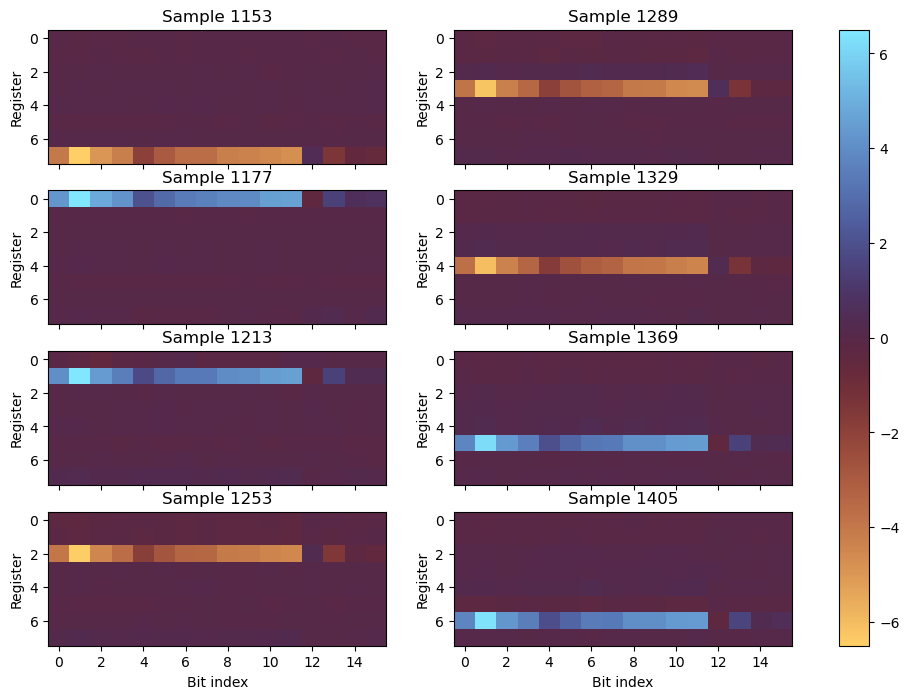

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import json

pois = [1153, 1177, 1213, 1253, 1289, 1329, 1369, 1405]
hw_datafolder = "./misc/hamming_weight_fit"

all_coefficients = []
for poi in pois:
    with open(f"{hw_datafolder}/poi{poi}.json", 'r') as f:
        coefficients = json.load(f)["coefficients"]
        coefficients = np.array(coefficients)

    #coefficients = np.sign(coefficients) * np.log1p(np.abs(coefficients))

    block1 = coefficients[:, :16]
    block2 = coefficients[:, 16:]

    all_coefficients.append(block1)


fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12,8), sharex=True)

vmin = min(block1.min(), block2.min())
vmax = max(block1.max(), block2.max())

vmin = -2.5
vmax = 2.5

vmax = 6.5
vmin = -6.5

for axx in range(2):
    for axy in range(4):

        poi_idx = axx * 4 + axy

        im1 = axes[axy,axx].imshow(all_coefficients[poi_idx], cmap="managua", aspect='auto', vmin=vmin, vmax=vmax)
        axes[axy,axx].set_title(f"Sample {pois[poi_idx]}")
        axes[axy,axx].set_ylabel("Register")

        #im2 = axes[1].imshow(block2, aspect='auto', vmin=vmin, vmax=vmax)
        #axes[1].set_title("POI 1177 – Block 2")
        #axes[1].set_ylabel("Register")

axes[3][0].set_xlabel("Bit index")
axes[3][1].set_xlabel("Bit index")

fig.colorbar(im1, ax=axes)

#plt.tight_layout()
plt.show()